Explore Pandas 

In [2]:
# Standard convention for importing the libraries
import pandas as pd
import seaborn as sns  # Imported as 'sns' by convention

In [3]:
# Load the restaurant tips dataset
df = sns.load_dataset("tips")

# Display the first few rows to verify
print(df.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [14]:
# Understand the data - show structure of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
 7   tip_pct     244 non-null    float64 
dtypes: category(4), float64(3), int64(1)
memory usage: 9.3 KB


In [15]:
# Get summary statistics
df.describe()

,total_bill,tip,size,tip_pct
count,244.000000,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672,16.080258
std,8.902412,1.383638,0.951100,6.107220
min,3.070000,1.000000,1.000000,3.563814
25%,13.347500,2.000000,2.000000,12.912736
50%,17.795000,2.900000,2.000000,15.476977
75%,24.127500,3.562500,3.000000,19.147549
max,50.810000,10.000000,6.000000,71.034483


In [16]:
# Check for missing values
print(df.isnull().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
tip_pct       0
dtype: int64


In [17]:
# Explore columns
# Value counts for a categorical column
print(df['day'].value_counts())

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [18]:
# Average tip amount
df['tip'].mean()

np.float64(2.99827868852459)

In [19]:
# Calculate correlation between tip and total_bill
correlation = df['tip'].corr(df['total_bill'])
print(f"Correlation between tip and total bill: {correlation:.3f}")

Correlation between tip and total bill: 0.676


In [31]:
# Common transformations
# Who tipped more than $5?
high_tippers = df[df['tip'] > 5]
#high_tippers = df.query('tip > 5')
print(high_tippers)

     total_bill    tip     sex smoker   day    time  size    tip_pct
23        39.42   7.58    Male     No   Sat  Dinner     4  19.228818
44        30.40   5.60    Male     No   Sun  Dinner     4  18.421053
47        32.40   6.00    Male     No   Sun  Dinner     4  18.518519
52        34.81   5.20  Female     No   Sun  Dinner     4  14.938236
59        48.27   6.73    Male     No   Sat  Dinner     4  13.942407
85        34.83   5.17  Female     No  Thur   Lunch     4  14.843526
88        24.71   5.85    Male     No  Thur   Lunch     2  23.674626
116       29.93   5.07    Male     No   Sun  Dinner     4  16.939526
141       34.30   6.70    Male     No  Thur   Lunch     6  19.533528
155       29.85   5.14  Female     No   Sun  Dinner     5  17.219430
170       50.81  10.00    Male    Yes   Sat  Dinner     3  19.681165
172        7.25   5.15    Male    Yes   Sun  Dinner     2  71.034483
181       23.33   5.65    Male    Yes   Sun  Dinner     2  24.217745
183       23.17   6.50    Male    

In [11]:
#Add tip% column
df['tip_pct'] = df['tip'] / df['total_bill'] * 100
print(df.head())

   total_bill   tip     sex smoker  day    time  size    tip_pct
0       16.99  1.01  Female     No  Sun  Dinner     2   5.944673
1       10.34  1.66    Male     No  Sun  Dinner     3  16.054159
2       21.01  3.50    Male     No  Sun  Dinner     3  16.658734
3       23.68  3.31    Male     No  Sun  Dinner     2  13.978041
4       24.59  3.61  Female     No  Sun  Dinner     4  14.680765


In [5]:
# Group by 'day' and calculate the mean tip
mean_tips_by_day = df.groupby('day')['tip'].mean()
print(mean_tips_by_day)

day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64


C:\Users\Hp 2022\AppData\Local\Temp\ipykernel_26008\3312727169.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tips_by_day = df.groupby('day')['tip'].mean()


In [12]:
#sort to find the seven biggest tips
top_tips = df.sort_values('tip', ascending=False).head(7)
#top_tips = df.nlargest(7, 'tip')
print(top_tips)

     total_bill    tip     sex smoker   day    time  size    tip_pct
170       50.81  10.00    Male    Yes   Sat  Dinner     3  19.681165
212       48.33   9.00    Male     No   Sat  Dinner     4  18.621974
23        39.42   7.58    Male     No   Sat  Dinner     4  19.228818
59        48.27   6.73    Male     No   Sat  Dinner     4  13.942407
141       34.30   6.70    Male     No  Thur   Lunch     6  19.533528
183       23.17   6.50    Male    Yes   Sun  Dinner     4  28.053517
214       28.17   6.50  Female    Yes   Sat  Dinner     3  23.074192


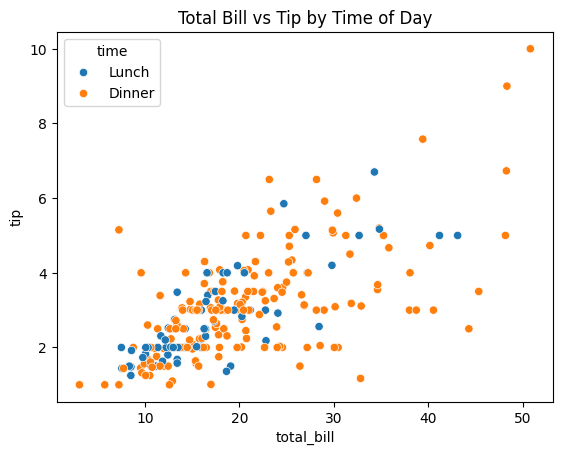

In [13]:
import matplotlib.pyplot as plt
# Scatter plot of total_bill vs tip, colored by time
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time')
plt.title('Total Bill vs Tip by Time of Day')   
plt.show()

In [28]:
# Try these:

# 1. How would you find the average tip *per smoker/non-smoker*?
average_tips_by_smoker = df.groupby('smoker')['tip'].mean()
# 2. How do you display only rows where the tip was greater than 15%?
high_percentage_tips = df[df['tip_pct'] > 15]
# 3. How many lunch vs dinner transactions are in the dataset?
meal_counts = df['time'].value_counts()
print(meal_counts)

print(f"Average:\n {average_tips_by_smoker} \n")
print(f"Tip was greater than 15% :\n {high_percentage_tips} \n")
print(f"Lunch vs dinner transactions :\n {meal_counts} \n")

time
Dinner    176
Lunch      68
Name: count, dtype: int64
Average:
 smoker
Yes    3.008710
No     2.991854
Name: tip, dtype: float64 

Tip was greater than 15% :
      total_bill   tip     sex smoker   day    time  size    tip_pct
1         10.34  1.66    Male     No   Sun  Dinner     3  16.054159
2         21.01  3.50    Male     No   Sun  Dinner     3  16.658734
5         25.29  4.71    Male     No   Sun  Dinner     4  18.623962
6          8.77  2.00    Male     No   Sun  Dinner     2  22.805017
9         14.78  3.23    Male     No   Sun  Dinner     2  21.853857
..          ...   ...     ...    ...   ...     ...   ...        ...
231       15.69  3.00    Male    Yes   Sat  Dinner     3  19.120459
232       11.61  3.39    Male     No   Sat  Dinner     2  29.198966
234       15.53  3.00    Male    Yes   Sat  Dinner     2  19.317450
239       29.03  5.92    Male     No   Sat  Dinner     3  20.392697
243       18.78  3.00  Female     No  Thur  Dinner     2  15.974441

[135 rows x 8 colum

C:\Users\Hp 2022\AppData\Local\Temp\ipykernel_26008\4160053102.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_tips_by_smoker = df.groupby('smoker')['tip'].mean()
